In [1]:
import os
import pandas as pd
import numpy as np
from collections import defaultdict 
import matplotlib.pyplot as plt
import importlib
import utils  
importlib.reload(utils)
from utils import * 

In [2]:
home = "C:/Users/maksiaevai.NCBI_NT/Documents/Avian_Flu_Files/" # Combinations/NCBI_Virus_Andersen_GISAID/11-01-2021--11-14-2025_Antarctica_North_America_South_America/unassigned/"
unassigned = home + "Other/South_America/"
os.chdir(unassigned)

In [3]:
def calculate_ns(sequence, ref_length):
    allowable_characters = ["A", "T", "G", "C", "a", "t", "g", "c"] #, "-"] # Anything else is N or other?
    other_characters = 0
    for character in sequence:
        if character not in allowable_characters:
            other_characters += 1
    proportion_ns = other_characters/ref_length
    return proportion_ns

C:/Users/maksiaevai.NCBI_NT/Documents/Avian_Flu_Files/Other/South_America/segments/1_PB2_Concatenated_SAm_Revisions_greenorange.fasta
                                           full_header  \
0    >A/Avian/Argentina/1762-2/2023|H5N1|EPI-ISL-18...   
1    >A/Avian/Argentina/1790-5/2023|H5N1|EPI-ISL-18...   
2    >A/Avian/Argentina/579-5/2023|H5N1|EPI-ISL-186...   
3    >A/Avian/Argentina/586-4/2023|H5N1|EPI-ISL-186...   
4    >A/avian/Peru/AISA0446/2022|H5N1|EPI-ISL-17805...   
..                                                 ...   
371  >A/Southern-Elephant-Seal/Jason-Harbour/141078...   
372  >A/southern-elephant-seal/Kerguelen/24P023433/...   
373  >A/southern-elephant-seal/Kerguelen/24P023439/...   
374  >A/Southern-fulmar/Falkland-Islands/133789/202...   
375  >A/Southern-Fulmar/Falkland-Islands/138870/202...   

                                              sequence  length  proportion_ns  
0    ATGGAGAGAATAAAAGAACTAAGAGATCTAATGTCACAGTCTCGCA...    2281       0.000438  
1    ATGG

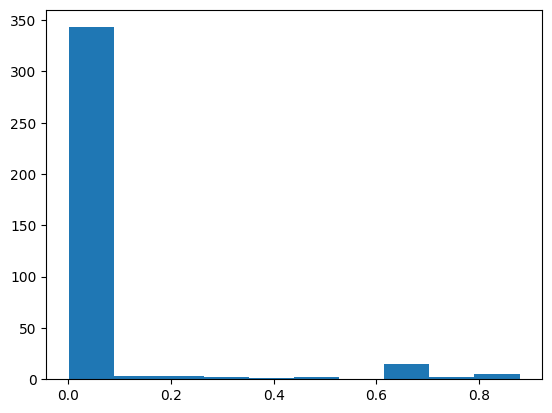

C:/Users/maksiaevai.NCBI_NT/Documents/Avian_Flu_Files/Other/South_America/segments/2_PB1_Concatenated_SAm_Revisions_greenorange.fasta
                                           full_header  \
0    >A/Avian/Argentina/1762-2/2023|H5N1|EPI-ISL-18...   
1    >A/Avian/Argentina/1790-5/2023|H5N1|EPI-ISL-18...   
2    >A/Avian/Argentina/579-5/2023|H5N1|EPI-ISL-186...   
3    >A/Avian/Argentina/586-4/2023|H5N1|EPI-ISL-186...   
4    >A/avian/Peru/AISA0446/2022|H5N1|EPI-ISL-17805...   
..                                                 ...   
371  >A/Southern-Elephant-Seal/Jason-Harbour/141078...   
372  >A/southern-elephant-seal/Kerguelen/24P023433/...   
373  >A/southern-elephant-seal/Kerguelen/24P023439/...   
374  >A/Southern-fulmar/Falkland-Islands/133789/202...   
375  >A/Southern-Fulmar/Falkland-Islands/138870/202...   

                                              sequence  length  proportion_ns  
0    ATGGATGTCAATCCGACTTTACTTTTCTTGAAGGTTCCAGCGCAAA...    2275       0.000440  
1    ATGG

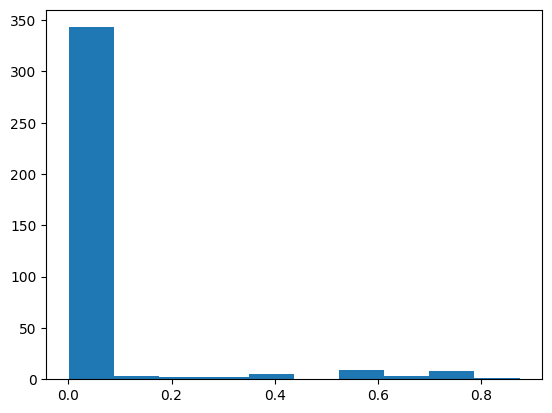

C:/Users/maksiaevai.NCBI_NT/Documents/Avian_Flu_Files/Other/South_America/segments/3_PA_Concatenated_SAm_Revisions_greenorange.fasta
                                           full_header  \
0    >A/Avian/Argentina/1762-2/2023|H5N1|EPI-ISL-18...   
1    >A/Avian/Argentina/1790-5/2023|H5N1|EPI-ISL-18...   
2    >A/Avian/Argentina/579-5/2023|H5N1|EPI-ISL-186...   
3    >A/Avian/Argentina/586-4/2023|H5N1|EPI-ISL-186...   
4    >A/avian/Peru/AISA0446/2022|H5N1|EPI-ISL-17805...   
..                                                 ...   
371  >A/Southern-Elephant-Seal/Jason-Harbour/141078...   
372  >A/southern-elephant-seal/Kerguelen/24P023433/...   
373  >A/southern-elephant-seal/Kerguelen/24P023439/...   
374  >A/Southern-fulmar/Falkland-Islands/133789/202...   
375  >A/Southern-Fulmar/Falkland-Islands/138870/202...   

                                              sequence  length  proportion_ns  
0    ATGGAAGACTTTGTGCGACAATGCTTCAATCCAATGATTGTCGAGC...    2152       0.000465  
1    ATGGA

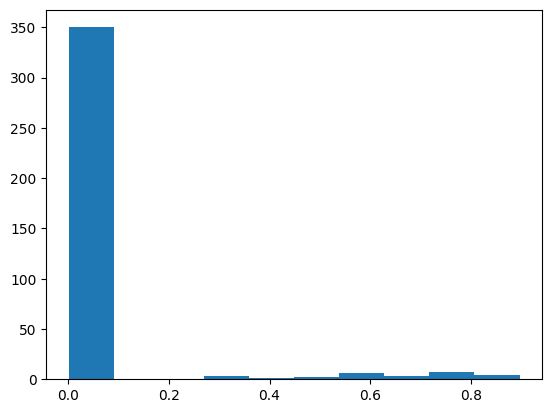

C:/Users/maksiaevai.NCBI_NT/Documents/Avian_Flu_Files/Other/South_America/segments/4_HA_Concatenated_SAm_Revisions_greenorange.fasta
                                           full_header  \
0    >A/Avian/Argentina/1762-2/2023|H5N1|EPI-ISL-18...   
1    >A/Avian/Argentina/1790-5/2023|H5N1|EPI-ISL-18...   
2    >A/Avian/Argentina/579-5/2023|H5N1|EPI-ISL-186...   
3    >A/Avian/Argentina/586-4/2023|H5N1|EPI-ISL-186...   
4    >A/avian/Peru/AISA0446/2022|H5N1|EPI-ISL-17805...   
..                                                 ...   
371  >A/Southern-Elephant-Seal/Jason-Harbour/141078...   
372  >A/southern-elephant-seal/Kerguelen/24P023433/...   
373  >A/southern-elephant-seal/Kerguelen/24P023439/...   
374  >A/Southern-fulmar/Falkland-Islands/133789/202...   
375  >A/Southern-Fulmar/Falkland-Islands/138870/202...   

                                              sequence  length  proportion_ns  
0    ATGGAGAACATAGTACTACTTCTTGCAATAGTTAGCCTTGTTAAAA...    1705       0.000587  
1    ATGGA

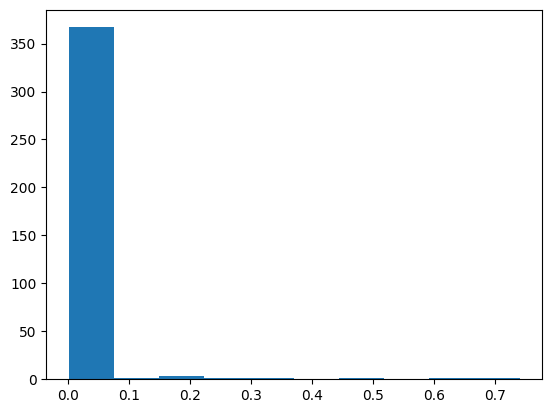

C:/Users/maksiaevai.NCBI_NT/Documents/Avian_Flu_Files/Other/South_America/segments/5_NP_Concatenated_SAm_Revisions_greenorange.fasta
                                           full_header  \
0    >A/Avian/Argentina/1762-2/2023|H5N1|EPI-ISL-18...   
1    >A/Avian/Argentina/1790-5/2023|H5N1|EPI-ISL-18...   
2    >A/Avian/Argentina/579-5/2023|H5N1|EPI-ISL-186...   
3    >A/Avian/Argentina/586-4/2023|H5N1|EPI-ISL-186...   
4    >A/avian/Peru/AISA0446/2022|H5N1|EPI-ISL-17805...   
..                                                 ...   
371  >A/Southern-Elephant-Seal/Jason-Harbour/141078...   
372  >A/southern-elephant-seal/Kerguelen/24P023433/...   
373  >A/southern-elephant-seal/Kerguelen/24P023439/...   
374  >A/Southern-fulmar/Falkland-Islands/133789/202...   
375  >A/Southern-Fulmar/Falkland-Islands/138870/202...   

                                              sequence  length  proportion_ns  
0    ATGGCGTCTCAAGGCACCAAACGATCCTATGAACAAATGGAAACTG...    1498       0.000668  
1    ATGGC

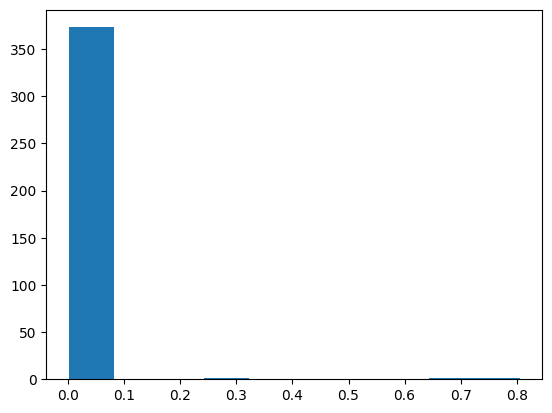

C:/Users/maksiaevai.NCBI_NT/Documents/Avian_Flu_Files/Other/South_America/segments/6_NA_Concatenated_SAm_Revisions_greenorange.fasta
                                           full_header  \
0    >A/Avian/Argentina/1762-2/2023|H5N1|EPI-ISL-18...   
1    >A/Avian/Argentina/1790-5/2023|H5N1|EPI-ISL-18...   
2    >A/Avian/Argentina/579-5/2023|H5N1|EPI-ISL-186...   
3    >A/Avian/Argentina/586-4/2023|H5N1|EPI-ISL-186...   
4    >A/avian/Peru/AISA0446/2022|H5N1|EPI-ISL-17805...   
..                                                 ...   
371  >A/Southern-Elephant-Seal/Jason-Harbour/141078...   
372  >A/southern-elephant-seal/Kerguelen/24P023433/...   
373  >A/southern-elephant-seal/Kerguelen/24P023439/...   
374  >A/Southern-fulmar/Falkland-Islands/133789/202...   
375  >A/Southern-Fulmar/Falkland-Islands/138870/202...   

                                              sequence  length  proportion_ns  
0    ATGAATCCAAATCAAAAGATAACAACCATTGGATCAATCTGTATGG...    1411       0.000709  
1    ATGAA

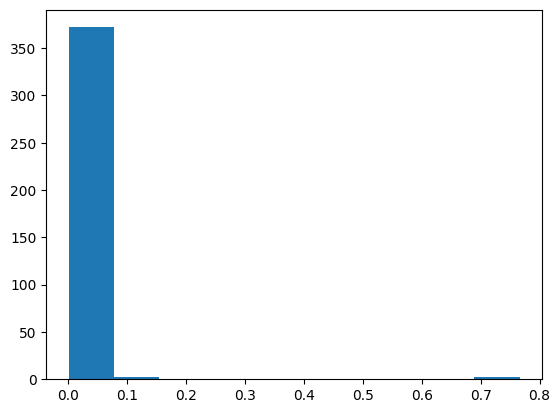

C:/Users/maksiaevai.NCBI_NT/Documents/Avian_Flu_Files/Other/South_America/segments/7_MP_Concatenated_SAm_Revisions_greenorange.fasta
                                           full_header  \
0    >A/Avian/Argentina/1762-2/2023|H5N1|EPI-ISL-18...   
1    >A/Avian/Argentina/1790-5/2023|H5N1|EPI-ISL-18...   
2    >A/Avian/Argentina/579-5/2023|H5N1|EPI-ISL-186...   
3    >A/Avian/Argentina/586-4/2023|H5N1|EPI-ISL-186...   
4    >A/avian/Peru/AISA0446/2022|H5N1|EPI-ISL-17805...   
..                                                 ...   
371  >A/Southern-Elephant-Seal/Jason-Harbour/141078...   
372  >A/southern-elephant-seal/Kerguelen/24P023433/...   
373  >A/southern-elephant-seal/Kerguelen/24P023439/...   
374  >A/Southern-fulmar/Falkland-Islands/133789/202...   
375  >A/Southern-Fulmar/Falkland-Islands/138870/202...   

                                              sequence  length  proportion_ns  
0    ATGAGTCTTCTAACCGAGGTCGAAACGTACGTTCTCTCTATCGTCC...     985       0.003046  
1    ATGAG

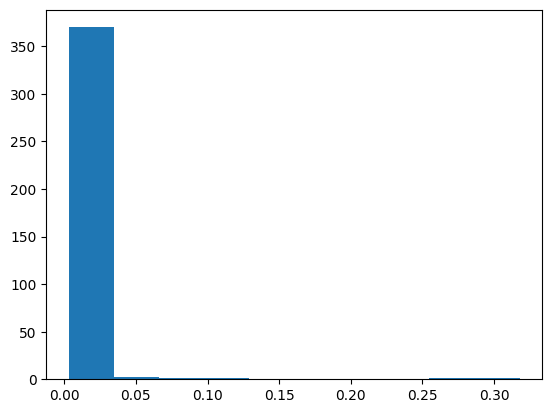

C:/Users/maksiaevai.NCBI_NT/Documents/Avian_Flu_Files/Other/South_America/segments/8_NS_Concatenated_SAm_Revisions_greenorange.fasta
                                           full_header  \
0    >A/Avian/Argentina/1762-2/2023|H5N1|EPI-ISL-18...   
1    >A/Avian/Argentina/1790-5/2023|H5N1|EPI-ISL-18...   
2    >A/Avian/Argentina/579-5/2023|H5N1|EPI-ISL-186...   
3    >A/Avian/Argentina/586-4/2023|H5N1|EPI-ISL-186...   
4    >A/avian/Peru/AISA0446/2022|H5N1|EPI-ISL-17805...   
..                                                 ...   
371  >A/Southern-Elephant-Seal/Jason-Harbour/141078...   
372  >A/southern-elephant-seal/Kerguelen/24P023433/...   
373  >A/southern-elephant-seal/Kerguelen/24P023439/...   
374  >A/Southern-fulmar/Falkland-Islands/133789/202...   
375  >A/Southern-Fulmar/Falkland-Islands/138870/202...   

                                              sequence  length  proportion_ns  
0    ATGGATTCCAACACTGTGTCAAGCTTTCAGGTAGACTGCTTTCTTT...     841       0.003567  
1    ATGGA

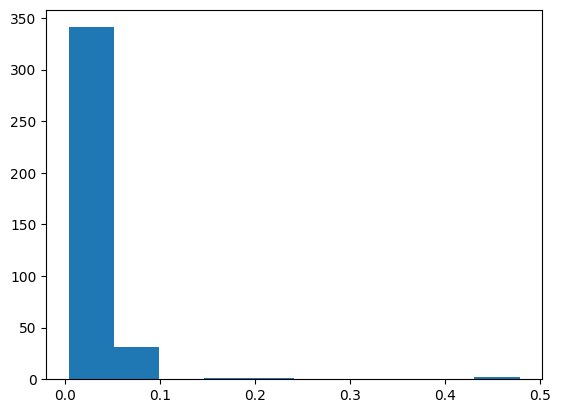

In [4]:
dfs = defaultdict(list)
for dirpath, dirs, files in os.walk(unassigned + "segments/"):
    if len(files) > 0: # If we have any files that need to be moved
        for file in files:
            file_name = os.path.join(dirpath, file)
            segment = file_name.split("/")[-1].split("_")[1]
            df = df_from_fasta(file_name)
            # df["Accession"] = df["full_header"].apply(lambda x: x.split("|")[0])
            df["length"] = df["sequence"].apply(len)
            df["proportion_ns"] = df["sequence"].apply(lambda x: calculate_ns(x, df["length"].max()))
            print(file_name)
            print(df)
            dfs[segment].append(df)
            plt.hist(df["proportion_ns"])
            plt.show()
    break 
# print(dfs[dfs.keys()[0]])

In [5]:
# Separate high quality from low-quality. Threshold: 0.3 Ns

hd_dfs = []
lq_dfs = []
for segment in dfs: 
    for df in segment:
        print(df)
        hd_df = df[df["proportion_ns"] <= 0.02]
        lq_df = df[df["proportion_ns"] > 0.02]
        hd_dfs.append(hd_df)
        lq_dfs.append(lq_df)

print(hd_dfs["PB2"][0])
lq_dfs

P


TypeError: string indices must be integers, not 'str'

In [ ]:
# # Keep entries that have only high-quality sequences in each segment

# # complete_df = pd.DataFrame()
# # index = 0
# # for df in hd_dfs:
# #     index_compare = 0
# #     for df_compare in hd_dfs:
# #         if index != index_compare:
# #             print(pd.concat([df, df_compare], join="inner").drop_duplicates(subset="full_header"))
# #             complete_df = pd.concat([complete_df, pd.concat([df, df_compare], join="inner").drop_duplicates(subset="full_header")])
# #         index_compare += 1
# #     index += 1

# combined = pd.concat(hd_dfs)

# # complete_df = complete_df.drop_duplicates(subset="full_header")

# df_counts = combined.groupby(combined.full_header, as_index=False).size()
# complete_df = df_counts[df_counts["size"] == 8]

# print(df_counts)

# print(complete_df["full_header"])

                                           full_header  size
0    >A/Antarctic-Fur-Seal/Jason-Harbour/141037/202...     8
1    >A/Antarctic-tern/King-Edward-Point/141271/202...     8
2    >A/Avian/Argentina/1762-2/2023|H5N1|EPI-ISL-18...     8
3    >A/Avian/Argentina/1790-5/2023|H5N1|EPI-ISL-18...     8
4    >A/Avian/Argentina/579-5/2023|H5N1|EPI-ISL-186...     8
..                                                 ...   ...
371  >A/turkey/Valparaiso/245562-1/2023|H5N1|EPI-IS...     8
372  >A/turkey/Valparaiso/245886-1/2023|H5N1|EPI-IS...     8
373  >A/turkey/Valparaiso/245886-3/2023|H5N1|EPI-IS...     8
374  >A/turkey/Valparaiso/245886-5/2023|H5N1|EPI-IS...     8
375  >A/turkey/Valparaiso/248976-12/2023|H5N1|EPI-I...     8

[376 rows x 2 columns]
0      >A/Antarctic-Fur-Seal/Jason-Harbour/141037/202...
1      >A/Antarctic-tern/King-Edward-Point/141271/202...
2      >A/Avian/Argentina/1762-2/2023|H5N1|EPI-ISL-18...
3      >A/Avian/Argentina/1790-5/2023|H5N1|EPI-ISL-18...
4      >A/Avian/

In [ ]:
# os.chdir("other")

# concat_df = df_from_fasta("Unassigned_concat_1481.fasta")

In [ ]:
# complete = complete_df.merge(concat_df, on="full_header", how="inner") # .to_csv("complete_genomes_unassigned_11-01-2021--11-14-2025.csv")
# incomplete = df_counts[df_counts["size"] < 8].merge(concat_df, on="full_header", how="inner") # .to_csv("incomplete_genomes_unassigned_11-01-2021--11-14-2025.csv")

In [ ]:
# df_to_fasta(complete_df, "complete_genomes_unassigned_11-01-2021--11-14-2025.fasta", unassigned)
# # df_to_fasta(incomplete, "incomplete_genomes_unassigned_11-01-2021--11-14-2025.fasta", "C:/Users/maksiaevai.NCBI_NT/Documents/Avian_Flu_Files/Combinations/NCBI_Virus_Andersen_GISAID/11-01-2021--11-14-2025_Antarctica_North_America_South_America/unassigned/other/")

In [ ]:
# Take 10 random sequences from each segment from each genotype and put them in a file AFTER MAFFT-ing them 

